# StairNav-LLM Starter - Voice-guided delivery robot in a multi-floor building

Notebook này tiếp tục từ `ViVLN_starter_local_llm.ipynb`, nhưng đổi bài toán từ điều hướng trong hẻm sang **robot giao hàng trong tòa nhà nhiều tầng có cầu thang**.

Mục tiêu nghiên cứu MVP:

1. Nhận câu lệnh giao hàng bằng tiếng Việt, ban đầu qua text, sau đó qua voice-to-text.
2. Parse câu lệnh thành intent có cấu trúc: món cần giao, người nhận, phòng/tầng, ràng buộc.
3. Lập kế hoạch trên đồ thị tòa nhà có hành lang, phòng, cầu thang, thang máy.
4. Phát hiện lệnh mơ hồ/thiếu thông tin và hỏi lại thay vì đoán bừa.
5. Đánh giá bằng Success Rate, SPL, valid path rate, clarification rate.

Điểm nên claim trong CV/paper nhỏ:

> A Vietnamese voice-command interface for stair-aware indoor delivery navigation, combining LLM command grounding, topological route planning, clarification dialogue, and simulator-based execution.

## Bước 0 - Cài đặt

In [1]:
!pip install -q networkx matplotlib pandas pydantic transformers accelerate bitsandbytes sentencepiece
print("Đã cài xong thư viện lõi.")

Đã cài xong thư viện lõi.


    python-dotenv (>=0.13.*) ; extra == 'standard'
                   ~~~~~~~^

[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: C:\Users\84865\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## Bước 1 - Import và cấu hình

Notebook có thể chạy theo hai chế độ:

- `USE_LOCAL_LLM = False`: chạy nhanh bằng parser rule-based để kiểm tra pipeline.
- `USE_LOCAL_LLM = True`: tải LLM open-weight trên Colab GPU để làm zero-shot baseline.

Khuyên dùng lần đầu: để `False`, chạy hết notebook, sau đó bật `True`.

In [2]:
import json
import math
import re
from dataclasses import dataclass
from typing import Any

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from pydantic import BaseModel, Field, ValidationError

plt.rcParams["font.family"] = "DejaVu Sans"

USE_LOCAL_LLM = False
MODEL_NAME = "Qwen/Qwen2.5-3B-Instruct"  # đổi sang Qwen/Qwen3-8B nếu Colab GPU đủ RAM

print("USE_LOCAL_LLM:", USE_LOCAL_LLM)

USE_LOCAL_LLM: False


## Bước 2 - Xây topological map của tòa nhà

Ta biểu diễn tòa nhà thành đồ thị. Mỗi node là một vị trí robot có thể đứng: sảnh, hành lang, phòng, cầu thang, thang máy.

Ở MVP này, cầu thang là một **edge có thuộc tính** `mode="stairs"`, chưa cần mô phỏng từng bậc thang. Đây là cách tốt để tách bài toán semantic planning khỏi locomotion physics.

In [3]:
G = nx.Graph()

nodes = {
    "L1": {"name": "sảnh tầng 1", "floor": 1, "type": "lobby", "desc": "Sảnh chính tầng 1, gần quầy bảo vệ"},
    "C1": {"name": "hành lang tầng 1", "floor": 1, "type": "corridor", "desc": "Hành lang tầng 1 nối sảnh, phòng 101 và khu cầu thang"},
    "R101": {"name": "phòng 101", "floor": 1, "type": "room", "desc": "Phòng 101 - văn phòng hành chính"},
    "S1": {"name": "cầu thang tầng 1", "floor": 1, "type": "stairs", "desc": "Chân cầu thang ở tầng 1"},
    "E1": {"name": "thang máy tầng 1", "floor": 1, "type": "elevator", "desc": "Cửa thang máy tầng 1"},

    "S2": {"name": "cầu thang tầng 2", "floor": 2, "type": "stairs", "desc": "Chiếu nghỉ cầu thang tầng 2"},
    "E2": {"name": "thang máy tầng 2", "floor": 2, "type": "elevator", "desc": "Cửa thang máy tầng 2"},
    "C2": {"name": "hành lang tầng 2", "floor": 2, "type": "corridor", "desc": "Hành lang tầng 2, gần phòng lab robot"},
    "R201": {"name": "phòng 201", "floor": 2, "type": "room", "desc": "Phòng 201 - lab robot"},
    "R202": {"name": "phòng 202", "floor": 2, "type": "room", "desc": "Phòng 202 - phòng họp nhỏ"},

    "S3": {"name": "cầu thang tầng 3", "floor": 3, "type": "stairs", "desc": "Chiếu nghỉ cầu thang tầng 3"},
    "E3": {"name": "thang máy tầng 3", "floor": 3, "type": "elevator", "desc": "Cửa thang máy tầng 3"},
    "C3": {"name": "hành lang tầng 3", "floor": 3, "type": "corridor", "desc": "Hành lang tầng 3, khu văn phòng giảng viên"},
    "R301": {"name": "phòng 301", "floor": 3, "type": "room", "desc": "Phòng 301 - văn phòng thầy Nam"},
    "R302": {"name": "phòng 302", "floor": 3, "type": "room", "desc": "Phòng 302 - văn phòng cô Lan"},

    "S5": {"name": "cầu thang tầng 5", "floor": 5, "type": "stairs", "desc": "Chiếu nghỉ cầu thang tầng 5"},
    "E5": {"name": "thang máy tầng 5", "floor": 5, "type": "elevator", "desc": "Cửa thang máy tầng 5"},
    "C5": {"name": "hành lang tầng 5", "floor": 5, "type": "corridor", "desc": "Hành lang tầng 5, khu phòng nghiên cứu"},
    "R503": {"name": "phòng 503", "floor": 5, "type": "room", "desc": "Phòng 503 - nhóm AI"},
    "R504": {"name": "phòng 504", "floor": 5, "type": "room", "desc": "Phòng 504 - kho thiết bị"},
}

for node_id, attrs in nodes.items():
    G.add_node(node_id, **attrs)

edges = [
    ("L1", "C1", {"mode": "flat", "cost": 1}),
    ("C1", "R101", {"mode": "flat", "cost": 1}),
    ("C1", "S1", {"mode": "flat", "cost": 1}),
    ("C1", "E1", {"mode": "flat", "cost": 1}),

    ("S1", "S2", {"mode": "stairs", "cost": 3}),
    ("S2", "S3", {"mode": "stairs", "cost": 3}),
    ("S3", "S5", {"mode": "stairs", "cost": 6}),
    ("E1", "E2", {"mode": "elevator", "cost": 2}),
    ("E2", "E3", {"mode": "elevator", "cost": 2}),
    ("E3", "E5", {"mode": "elevator", "cost": 4}),

    ("S2", "C2", {"mode": "flat", "cost": 1}),
    ("E2", "C2", {"mode": "flat", "cost": 1}),
    ("C2", "R201", {"mode": "flat", "cost": 1}),
    ("C2", "R202", {"mode": "flat", "cost": 1}),

    ("S3", "C3", {"mode": "flat", "cost": 1}),
    ("E3", "C3", {"mode": "flat", "cost": 1}),
    ("C3", "R301", {"mode": "flat", "cost": 1}),
    ("C3", "R302", {"mode": "flat", "cost": 1}),

    ("S5", "C5", {"mode": "flat", "cost": 1}),
    ("E5", "C5", {"mode": "flat", "cost": 1}),
    ("C5", "R503", {"mode": "flat", "cost": 1}),
    ("C5", "R504", {"mode": "flat", "cost": 1}),
]
G.add_edges_from([(u, v, attrs) for u, v, attrs in edges])

ROOM_ALIASES = {
    "101": "R101", "phòng 101": "R101", "hanh chinh": "R101", "hành chính": "R101",
    "201": "R201", "phòng 201": "R201", "lab robot": "R201", "robot lab": "R201",
    "202": "R202", "phòng 202": "R202", "phòng họp": "R202",
    "301": "R301", "phòng 301": "R301", "thầy nam": "R301", "thay nam": "R301",
    "302": "R302", "phòng 302": "R302", "cô lan": "R302", "co lan": "R302",
    "503": "R503", "phòng 503": "R503", "nhóm ai": "R503", "nhom ai": "R503",
    "504": "R504", "phòng 504": "R504", "kho thiết bị": "R504", "kho thiet bi": "R504",
}


def describe_building(graph: nx.Graph) -> str:
    lines = []
    for nid, data in graph.nodes(data=True):
        neighbors = []
        for nb in graph.neighbors(nid):
            edge = graph.edges[nid, nb]
            neighbors.append(f"{nb}({edge['mode']}, cost={edge['cost']})")
        lines.append(
            f"- {nid}: {data['name']} | tầng {data['floor']} | loại {data['type']} | "
            f"{data['desc']} | nối tới: {', '.join(neighbors)}"
        )
    return "\n".join(lines)


print(describe_building(G))

- L1: sảnh tầng 1 | tầng 1 | loại lobby | Sảnh chính tầng 1, gần quầy bảo vệ | nối tới: C1(flat, cost=1)
- C1: hành lang tầng 1 | tầng 1 | loại corridor | Hành lang tầng 1 nối sảnh, phòng 101 và khu cầu thang | nối tới: L1(flat, cost=1), R101(flat, cost=1), S1(flat, cost=1), E1(flat, cost=1)
- R101: phòng 101 | tầng 1 | loại room | Phòng 101 - văn phòng hành chính | nối tới: C1(flat, cost=1)
- S1: cầu thang tầng 1 | tầng 1 | loại stairs | Chân cầu thang ở tầng 1 | nối tới: C1(flat, cost=1), S2(stairs, cost=3)
- E1: thang máy tầng 1 | tầng 1 | loại elevator | Cửa thang máy tầng 1 | nối tới: C1(flat, cost=1), E2(elevator, cost=2)
- S2: cầu thang tầng 2 | tầng 2 | loại stairs | Chiếu nghỉ cầu thang tầng 2 | nối tới: S1(stairs, cost=3), S3(stairs, cost=3), C2(flat, cost=1)
- E2: thang máy tầng 2 | tầng 2 | loại elevator | Cửa thang máy tầng 2 | nối tới: E1(elevator, cost=2), E3(elevator, cost=2), C2(flat, cost=1)
- C2: hành lang tầng 2 | tầng 2 | loại corridor | Hành lang tầng 2, gần phòng

## Bước 3 - Trực quan hóa tòa nhà

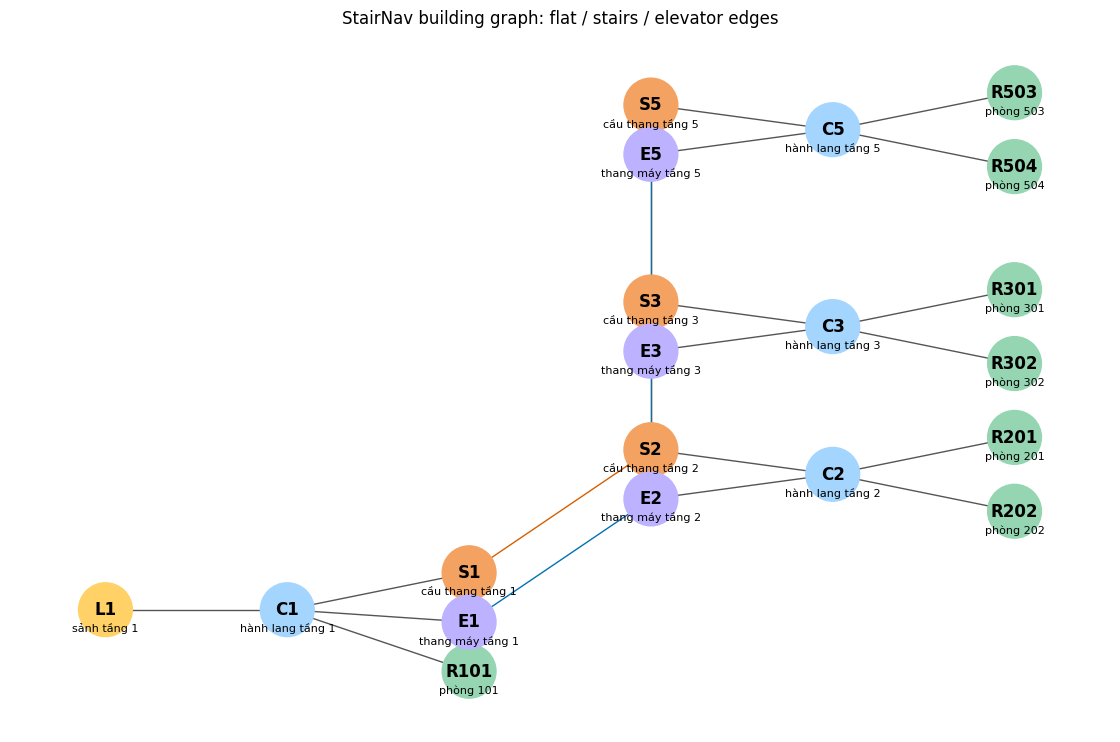

In [4]:
pos = {
    "L1": (0, 0), "C1": (1, 0), "R101": (2, -0.5), "S1": (2, 0.3), "E1": (2, -0.1),
    "S2": (3, 1.3), "E2": (3, 0.9), "C2": (4, 1.1), "R201": (5, 1.4), "R202": (5, 0.8),
    "S3": (3, 2.5), "E3": (3, 2.1), "C3": (4, 2.3), "R301": (5, 2.6), "R302": (5, 2.0),
    "S5": (3, 4.1), "E5": (3, 3.7), "C5": (4, 3.9), "R503": (5, 4.2), "R504": (5, 3.6),
}

edge_colors = []
for u, v in G.edges():
    mode = G.edges[u, v]["mode"]
    edge_colors.append({"flat": "#555555", "stairs": "#d65f00", "elevator": "#0072b2"}[mode])

node_colors = []
for n in G.nodes:
    t = G.nodes[n]["type"]
    node_colors.append({"lobby": "#ffd166", "corridor": "#a3d5ff", "room": "#95d5b2", "stairs": "#f4a261", "elevator": "#bdb2ff"}[t])

plt.figure(figsize=(11, 7))
nx.draw(G, pos, with_labels=True, node_color=node_colors, edge_color=edge_colors, node_size=1500, font_weight="bold")
labels = {nid: data["name"] for nid, data in G.nodes(data=True)}
for nid, (x, y) in pos.items():
    plt.text(x, y - 0.18, labels[nid], fontsize=8, ha="center")
plt.title("StairNav building graph: flat / stairs / elevator edges")
plt.axis("off")
plt.show()

## Bước 4 - Dataset lệnh giao hàng tiếng Việt

In [5]:
dataset = [
    {
        "id": "clear_503",
        "start": "L1",
        "instruction": "Đem tài liệu lên phòng 503 cho nhóm AI.",
        "item": "tài liệu",
        "destination": "R503",
        "requires_clarification": False,
    },
    {
        "id": "recipient_301",
        "start": "L1",
        "instruction": "Giao hộp thuốc cho thầy Nam.",
        "item": "hộp thuốc",
        "destination": "R301",
        "requires_clarification": False,
    },
    {
        "id": "lab_robot",
        "start": "L1",
        "instruction": "Mang linh kiện robot tới lab robot ở tầng 2.",
        "item": "linh kiện robot",
        "destination": "R201",
        "requires_clarification": False,
    },
    {
        "id": "meeting_room",
        "start": "R101",
        "instruction": "Từ phòng hành chính, đem biên bản tới phòng họp nhỏ.",
        "item": "biên bản",
        "destination": "R202",
        "requires_clarification": False,
    },
    {
        "id": "use_stairs",
        "start": "L1",
        "instruction": "Giao tài liệu tới phòng 302, ưu tiên đi cầu thang.",
        "item": "tài liệu",
        "destination": "R302",
        "requires_clarification": False,
        "preferred_vertical_mode": "stairs",
    },
    {
        "id": "use_elevator",
        "start": "L1",
        "instruction": "Mang laptop lên phòng 504, tránh cầu thang nếu có thể.",
        "item": "laptop",
        "destination": "R504",
        "requires_clarification": False,
        "preferred_vertical_mode": "elevator",
    },
    {
        "id": "ambiguous_room",
        "start": "L1",
        "instruction": "Giao cái hộp lên phòng của cô Lan.",
        "item": "cái hộp",
        "destination": "R302",
        "requires_clarification": False,
    },
    {
        "id": "missing_destination",
        "start": "L1",
        "instruction": "Giao gói hàng này cho giảng viên.",
        "item": "gói hàng",
        "destination": None,
        "requires_clarification": True,
        "clarification_target": "destination",
    },
    {
        "id": "missing_item",
        "start": "L1",
        "instruction": "Mang lên phòng 503 giúp tôi.",
        "item": None,
        "destination": "R503",
        "requires_clarification": True,
        "clarification_target": "item",
    },
]


def shortest_route(graph, start, goal, preferred_vertical_mode=None):
    def weight(u, v, attrs):
        cost = attrs["cost"]
        if preferred_vertical_mode == "stairs" and attrs["mode"] == "elevator":
            cost += 4
        if preferred_vertical_mode == "elevator" and attrs["mode"] == "stairs":
            cost += 4
        return cost

    return nx.shortest_path(graph, start, goal, weight=weight)


for sample in dataset:
    if sample["destination"]:
        sample["gt_path"] = shortest_route(
            G,
            sample["start"],
            sample["destination"],
            sample.get("preferred_vertical_mode"),
        )
    else:
        sample["gt_path"] = None

pd.DataFrame(dataset)

,id,start,instruction,item,destination,requires_clarification,gt_path,preferred_vertical_mode,clarification_target
0,clear_503,L1,Đem tài liệu lên phòng 503 cho nhóm AI.,tài liệu,R503,False,"[L1, C1, E1, E2, E3, E5, C5, R503]",NaN,NaN
1,recipient_301,L1,Giao hộp thuốc cho thầy Nam.,hộp thuốc,R301,False,"[L1, C1, E1, E2, E3, C3, R301]",NaN,NaN
2,lab_robot,L1,Mang linh kiện robot tới lab robot ở tầng 2.,linh kiện robot,R201,False,"[L1, C1, E1, E2, C2, R201]",NaN,NaN
3,meeting_room,R101,"Từ phòng hành chính, đem biên bản tới phòng họ...",biên bản,R202,False,"[R101, C1, E1, E2, C2, R202]",NaN,NaN
4,use_stairs,L1,"Giao tài liệu tới phòng 302, ưu tiên đi cầu th...",tài liệu,R302,False,"[L1, C1, S1, S2, S3, C3, R302]",stairs,NaN
5,use_elevator,L1,"Mang laptop lên phòng 504, tránh cầu thang nếu...",laptop,R504,False,"[L1, C1, E1, E2, E3, E5, C5, R504]",elevator,NaN
6,ambiguous_room,L1,Giao cái hộp lên phòng của cô Lan.,cái hộp,R302,False,"[L1, C1, E1, E2, E3, C3, R302]",NaN,NaN
7,missing_destination,L1,Giao gói hàng này cho giảng viên.,gói hàng,None,True,None,NaN,destination
8,missing_item,L1,Mang lên phòng 503 giúp tôi.,None,R503,True,"[L1, C1, E1, E2, E3, E5, C5, R503]",NaN,item


## Bước 5 - Schema cho LLM planner

Ta ép LLM trả JSON. Schema này quan trọng vì nó biến câu lệnh tự nhiên thành đối tượng có thể kiểm thử.

In [6]:
class DeliveryPlan(BaseModel):
    intent: str = Field(description="delivery, navigation, clarification, or unsupported")
    item: str | None = None
    destination: str | None = Field(default=None, description="Node id như R503 hoặc None nếu chưa rõ")
    preferred_vertical_mode: str | None = Field(default=None, description="stairs, elevator, hoặc None")
    needs_clarification: bool = False
    clarification_question: str | None = None
    path: list[str] = Field(default_factory=list)
    reasoning: str = ""


def extract_json(text: str) -> dict[str, Any]:
    match = re.search(r"\{.*\}", text, re.DOTALL)
    if not match:
        raise ValueError(f"Không tìm thấy JSON trong phản hồi: {text}")
    return json.loads(match.group(0))


def normalize_text(s: str) -> str:
    s = s.lower().strip()
    replacements = {
        "đ": "d",
        "ầ": "a", "ậ": "a", "ẩ": "a", "ẫ": "a", "ă": "a", "ắ": "a", "ằ": "a", "ặ": "a",
        "á": "a", "à": "a", "ạ": "a", "ả": "a", "ã": "a", "â": "a",
        "é": "e", "è": "e", "ẹ": "e", "ẻ": "e", "ẽ": "e", "ê": "e", "ế": "e", "ề": "e", "ệ": "e",
        "í": "i", "ì": "i", "ị": "i", "ỉ": "i", "ĩ": "i",
        "ó": "o", "ò": "o", "ọ": "o", "ỏ": "o", "õ": "o", "ô": "o", "ố": "o", "ồ": "o", "ộ": "o", "ơ": "o", "ớ": "o", "ờ": "o", "ợ": "o",
        "ú": "u", "ù": "u", "ụ": "u", "ủ": "u", "ũ": "u", "ư": "u", "ứ": "u", "ừ": "u", "ự": "u",
        "ý": "y", "ỳ": "y", "ỵ": "y", "ỷ": "y", "ỹ": "y",
    }
    for src, dst in replacements.items():
        s = s.replace(src, dst)
    return s

## Bước 6 - Baseline rule-based parser

Baseline này không nhằm thay thế LLM. Nó giúp:

1. Kiểm tra pipeline end-to-end trước khi tải model.
2. Làm baseline cổ điển trong báo cáo.
3. Tách lỗi parser khỏi lỗi route planner.

In [7]:
def parse_with_rules(instruction: str) -> DeliveryPlan:
    raw = instruction.lower()
    text = normalize_text(instruction)

    destination = None
    for alias, node_id in ROOM_ALIASES.items():
        if normalize_text(alias) in text or alias in raw:
            destination = node_id
            break

    preferred_vertical_mode = None
    if "cau thang" in text and ("uu tien" in text or "di cau thang" in text):
        preferred_vertical_mode = "stairs"
    if "tranh cau thang" in text or "thang may" in text:
        preferred_vertical_mode = "elevator"

    item_patterns = [
        r"(?:đem|giao|mang)\s+(.+?)\s+(?:lên|xuống|tới|đến|cho)",
        r"(?:dem|giao|mang)\s+(.+?)\s+(?:len|xuong|toi|den|cho)",
    ]
    item = None
    for pat in item_patterns:
        m = re.search(pat, raw)
        if m:
            item = m.group(1).strip()
            break

    if destination is None:
        return DeliveryPlan(
            intent="clarification",
            item=item,
            destination=None,
            preferred_vertical_mode=preferred_vertical_mode,
            needs_clarification=True,
            clarification_question="Bạn muốn robot giao tới phòng nào hoặc cho người nhận nào?",
            reasoning="Không xác định được phòng/người nhận từ câu lệnh.",
        )

    if item is None or item in {"", "lên", "len"}:
        return DeliveryPlan(
            intent="clarification",
            item=item,
            destination=destination,
            preferred_vertical_mode=preferred_vertical_mode,
            needs_clarification=True,
            clarification_question=f"Robot cần mang món gì tới {destination}?",
            reasoning="Xác định được điểm đến nhưng thiếu món hàng.",
        )

    return DeliveryPlan(
        intent="delivery",
        item=item,
        destination=destination,
        preferred_vertical_mode=preferred_vertical_mode,
        needs_clarification=False,
        reasoning="Parser rule-based tìm thấy món hàng và điểm đến.",
    )


for command in [
    "Đem tài liệu lên phòng 503 cho nhóm AI.",
    "Giao gói hàng này cho giảng viên.",
    "Mang lên phòng 503 giúp tôi.",
]:
    print(command)
    print(parse_with_rules(command).model_dump())
    print()

Đem tài liệu lên phòng 503 cho nhóm AI.
{'intent': 'delivery', 'item': 'tài liệu', 'destination': 'R503', 'preferred_vertical_mode': None, 'needs_clarification': False, 'clarification_question': None, 'path': [], 'reasoning': 'Parser rule-based tìm thấy món hàng và điểm đến.'}

Giao gói hàng này cho giảng viên.
{'intent': 'clarification', 'item': 'gói hàng này', 'destination': None, 'preferred_vertical_mode': None, 'needs_clarification': True, 'clarification_question': 'Bạn muốn robot giao tới phòng nào hoặc cho người nhận nào?', 'path': [], 'reasoning': 'Không xác định được phòng/người nhận từ câu lệnh.'}

Mang lên phòng 503 giúp tôi.
{'intent': 'clarification', 'item': None, 'destination': 'R503', 'preferred_vertical_mode': None, 'needs_clarification': True, 'clarification_question': 'Robot cần mang món gì tới R503?', 'path': [], 'reasoning': 'Xác định được điểm đến nhưng thiếu món hàng.'}



## Bước 7 - LLM planner zero-shot

In [8]:
if USE_LOCAL_LLM:
    import torch
    from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

    print("GPU khả dụng:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("Tên GPU:", torch.cuda.get_device_name(0))

    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_quant_type="nf4",
    )

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        quantization_config=bnb_config,
        device_map="auto",
    )
    model.eval()
    print(f"Đã nạp xong model: {MODEL_NAME}")
else:
    tokenizer = None
    model = None
    print("Bỏ qua tải LLM. Notebook đang chạy bằng rule-based baseline.")

Bỏ qua tải LLM. Notebook đang chạy bằng rule-based baseline.


In [9]:
def build_llm_prompt(graph, start_node: str, instruction: str) -> str:
    return f'''Bạn là planner cho robot giao hàng trong một tòa nhà nhiều tầng ở Việt Nam.
Tòa nhà là đồ thị. Robot chỉ được đi qua các cạnh có sẵn.
Các cạnh có mode: flat, stairs, elevator. Nếu người dùng ưu tiên/tránh cầu thang, hãy phản ánh trong preferred_vertical_mode.

Sơ đồ tòa nhà:
{describe_building(graph)}

Robot bắt đầu tại node: {start_node}
Câu lệnh tiếng Việt:
\"{instruction}\"

Hãy trả lời DUY NHẤT một JSON object theo schema:
{{
  "intent": "delivery|navigation|clarification|unsupported",
  "item": "tên món hàng hoặc null",
  "destination": "node id như R503 hoặc null",
  "preferred_vertical_mode": "stairs|elevator|null",
  "needs_clarification": true hoặc false,
  "clarification_question": "câu hỏi tiếng Việt hoặc null",
  "path": ["node bắt đầu", "..."] hoặc [],
  "reasoning": "giải thích ngắn 1-2 câu"
}}

Nếu thiếu món hàng hoặc thiếu điểm đến, đặt needs_clarification=true và không bịa thông tin.
'''


def apply_template(messages):
    try:
        return tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True, enable_thinking=False
        )
    except TypeError:
        return tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )


def call_local_llm_planner(graph, start_node: str, instruction: str, max_new_tokens: int = 500) -> DeliveryPlan:
    if not USE_LOCAL_LLM:
        raise RuntimeError("USE_LOCAL_LLM=False. Hãy dùng parse_with_rules hoặc bật LLM.")

    prompt = build_llm_prompt(graph, start_node, instruction)
    messages = [{"role": "user", "content": prompt}]
    text = apply_template(messages)
    inputs = tokenizer(text, return_tensors="pt").to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
        )

    generated = output_ids[0][inputs["input_ids"].shape[1]:]
    response_text = tokenizer.decode(generated, skip_special_tokens=True)
    data = extract_json(response_text)
    return DeliveryPlan(**data)

## Bước 8 - Route planner và simulator giao hàng

In [10]:
def complete_plan_with_route(graph, start_node: str, plan: DeliveryPlan) -> DeliveryPlan:
    if plan.needs_clarification or plan.destination is None:
        return plan

    if plan.destination not in graph.nodes:
        plan.needs_clarification = True
        plan.clarification_question = f"Điểm đến {plan.destination} không tồn tại trong bản đồ. Bạn muốn giao tới phòng nào?"
        plan.path = []
        return plan

    path = shortest_route(graph, start_node, plan.destination, plan.preferred_vertical_mode)
    return plan.model_copy(update={"path": path})


def edge_modes(graph, path):
    return [graph.edges[a, b]["mode"] for a, b in zip(path, path[1:])]


def simulate_delivery(graph, start_node: str, instruction: str, use_llm: bool = False):
    if use_llm:
        plan = call_local_llm_planner(graph, start_node, instruction)
    else:
        plan = parse_with_rules(instruction)

    plan = complete_plan_with_route(graph, start_node, plan)

    if plan.needs_clarification:
        return {
            "status": "needs_clarification",
            "question": plan.clarification_question,
            "plan": plan.model_dump(),
        }

    valid_edges = all(graph.has_edge(a, b) for a, b in zip(plan.path, plan.path[1:]))
    return {
        "status": "delivered" if valid_edges else "invalid_path",
        "item": plan.item,
        "destination": plan.destination,
        "path": plan.path,
        "edge_modes": edge_modes(graph, plan.path),
        "plan": plan.model_dump(),
    }


demo_commands = [
    "Đem tài liệu lên phòng 503 cho nhóm AI.",
    "Giao hộp thuốc cho thầy Nam.",
    "Mang laptop lên phòng 504, tránh cầu thang nếu có thể.",
    "Giao gói hàng này cho giảng viên.",
]

for cmd in demo_commands:
    print("COMMAND:", cmd)
    print(json.dumps(simulate_delivery(G, "L1", cmd, use_llm=False), ensure_ascii=False, indent=2))
    print()

COMMAND: Đem tài liệu lên phòng 503 cho nhóm AI.
{
  "status": "delivered",
  "item": "tài liệu",
  "destination": "R503",
  "path": [
    "L1",
    "C1",
    "E1",
    "E2",
    "E3",
    "E5",
    "C5",
    "R503"
  ],
  "edge_modes": [
    "flat",
    "flat",
    "elevator",
    "elevator",
    "elevator",
    "flat",
    "flat"
  ],
  "plan": {
    "intent": "delivery",
    "item": "tài liệu",
    "destination": "R503",
    "preferred_vertical_mode": null,
    "needs_clarification": false,
    "clarification_question": null,
    "path": [
      "L1",
      "C1",
      "E1",
      "E2",
      "E3",
      "E5",
      "C5",
      "R503"
    ],
    "reasoning": "Parser rule-based tìm thấy món hàng và điểm đến."
  }
}

COMMAND: Giao hộp thuốc cho thầy Nam.
{
  "status": "delivered",
  "item": "hộp thuốc",
  "destination": "R301",
  "path": [
    "L1",
    "C1",
    "E1",
    "E2",
    "E3",
    "C3",
    "R301"
  ],
  "edge_modes": [
    "flat",
    "flat",
    "elevator",
    "elevator

## Bước 9 - Đánh giá

In [11]:
def is_valid_path(graph, path):
    return bool(path) and all(graph.has_edge(a, b) for a, b in zip(path, path[1:]))


def success(pred_path, gt_path):
    if gt_path is None:
        return 0.0
    return 1.0 if pred_path and pred_path[-1] == gt_path[-1] else 0.0


def spl(pred_path, gt_path):
    if gt_path is None or success(pred_path, gt_path) == 0:
        return 0.0
    gt_len = max(len(gt_path) - 1, 1)
    pred_len = max(len(pred_path) - 1, 1)
    return gt_len / max(gt_len, pred_len)


def evaluate(samples, use_llm=False):
    rows = []
    for sample in samples:
        out = simulate_delivery(G, sample["start"], sample["instruction"], use_llm=use_llm)
        pred_path = out.get("path", [])
        valid = is_valid_path(G, pred_path)
        needs_clarification = out["status"] == "needs_clarification"
        expected_clarification = sample["requires_clarification"]

        rows.append({
            "id": sample["id"],
            "instruction": sample["instruction"],
            "expected_clarification": expected_clarification,
            "needs_clarification": needs_clarification,
            "clarification_correct": needs_clarification == expected_clarification,
            "gt_path": sample["gt_path"],
            "pred_path": pred_path,
            "valid_path": valid,
            "success": success(pred_path, sample["gt_path"]) if not expected_clarification else float(needs_clarification),
            "spl": spl(pred_path, sample["gt_path"]) if not expected_clarification else 0.0,
            "status": out["status"],
        })
    return pd.DataFrame(rows)


df = evaluate(dataset, use_llm=False)
display(df)

print("Valid path rate:", df["valid_path"].mean())
print("Clarification accuracy:", df["clarification_correct"].mean())
print("Task success proxy:", df["success"].mean())
print("Mean SPL on executable tasks:", df.loc[~df["expected_clarification"], "spl"].mean())

,id,instruction,expected_clarification,needs_clarification,clarification_correct,gt_path,pred_path,valid_path,success,spl,status
0,clear_503,Đem tài liệu lên phòng 503 cho nhóm AI.,False,False,True,"[L1, C1, E1, E2, E3, E5, C5, R503]","[L1, C1, E1, E2, E3, E5, C5, R503]",True,1.0,1.0,delivered
1,recipient_301,Giao hộp thuốc cho thầy Nam.,False,False,True,"[L1, C1, E1, E2, E3, C3, R301]","[L1, C1, E1, E2, E3, C3, R301]",True,1.0,1.0,delivered
2,lab_robot,Mang linh kiện robot tới lab robot ở tầng 2.,False,False,True,"[L1, C1, E1, E2, C2, R201]","[L1, C1, E1, E2, C2, R201]",True,1.0,1.0,delivered
3,meeting_room,"Từ phòng hành chính, đem biên bản tới phòng họ...",False,False,True,"[R101, C1, E1, E2, C2, R202]",[R101],True,0.0,0.0,delivered
4,use_stairs,"Giao tài liệu tới phòng 302, ưu tiên đi cầu th...",False,False,True,"[L1, C1, S1, S2, S3, C3, R302]","[L1, C1, S1, S2, S3, C3, R302]",True,1.0,1.0,delivered
5,use_elevator,"Mang laptop lên phòng 504, tránh cầu thang nếu...",False,False,True,"[L1, C1, E1, E2, E3, E5, C5, R504]","[L1, C1, E1, E2, E3, E5, C5, R504]",True,1.0,1.0,delivered
6,ambiguous_room,Giao cái hộp lên phòng của cô Lan.,False,False,True,"[L1, C1, E1, E2, E3, C3, R302]","[L1, C1, E1, E2, E3, C3, R302]",True,1.0,1.0,delivered
7,missing_destination,Giao gói hàng này cho giảng viên.,True,True,True,None,[],False,1.0,0.0,needs_clarification
8,missing_item,Mang lên phòng 503 giúp tôi.,True,True,True,"[L1, C1, E1, E2, E3, E5, C5, R503]",[],False,1.0,0.0,needs_clarification


Valid path rate: 0.7777777777777778
Clarification accuracy: 1.0
Task success proxy: 0.8888888888888888
Mean SPL on executable tasks: 0.8571428571428571


## Bước 10 - Đóng góp kỹ thuật: Vision + Map Fusion

Đây là hướng contribution nên phát triển:

**Map-only navigation** giả định bản đồ luôn đúng. Nhưng robot thật có camera/depth/LiDAR, nên nó có thể nhìn thấy biển phòng, hành lang bị chặn, cửa thang máy, hoặc cầu thang. Ta sẽ thêm một lớp **vision belief**:

- Bản đồ cho biết node/cạnh nào tồn tại.
- Vision cho biết robot đang thấy landmark nào, confidence bao nhiêu.
- Planner kết hợp hai nguồn này để cập nhật affordance: cạnh nào nên đi, cạnh nào bị chặn, điểm đến nào khớp quan sát.

Ở notebook starter, vision được giả lập bằng detection list để chạy được trên Colab. Sau này thay `simulate_robot_vision(...)` bằng object detector thật từ RGB-D/simulator.

In [12]:
VISION_SIGNATURES = {
    "L1": ["quầy bảo vệ", "sảnh chính", "biển tầng 1"],
    "C1": ["hành lang tầng 1", "biển phòng 101", "cầu thang"],
    "S1": ["cầu thang", "biển tầng 1"],
    "E1": ["thang máy", "nút gọi thang"],
    "C2": ["hành lang tầng 2", "biển lab robot", "biển phòng 201"],
    "R201": ["biển phòng 201", "lab robot"],
    "C3": ["hành lang tầng 3", "biển phòng 301", "biển phòng 302"],
    "R301": ["biển phòng 301", "văn phòng thầy Nam"],
    "R302": ["biển phòng 302", "văn phòng cô Lan"],
    "C5": ["hành lang tầng 5", "biển phòng 503", "biển phòng 504"],
    "R503": ["biển phòng 503", "nhóm AI"],
    "R504": ["biển phòng 504", "kho thiết bị"],
}


def simulate_robot_vision(node_id: str, blocked_edges=None):
    """Giả lập camera/vision output tại node hiện tại.

    Trong simulator thật, output này có thể đến từ RGB-D camera + detector:
    - room sign OCR
    - stair/elevator detector
    - obstacle detector
    """
    blocked_edges = blocked_edges or set()
    detections = []
    for label in VISION_SIGNATURES.get(node_id, []):
        detections.append({"label": label, "confidence": 0.85})
    for u, v in blocked_edges:
        if u == node_id or v == node_id:
            detections.append({"label": f"blocked_edge:{u}-{v}", "confidence": 0.95})
    return detections


def vision_support_for_node(detections, node_id: str) -> float:
    """Score 0..1: observation hiện tại có giống node ứng viên không."""
    signatures = VISION_SIGNATURES.get(node_id, [])
    if not signatures:
        return 0.15

    score = 0.0
    labels = [d["label"].lower() for d in detections]
    for sig in signatures:
        sig_norm = sig.lower()
        for det, label in zip(detections, labels):
            if sig_norm in label or label in sig_norm:
                score = max(score, det["confidence"])
    return max(score, 0.05)


def detect_blocked_edges(detections):
    blocked = set()
    for det in detections:
        label = det["label"]
        if label.startswith("blocked_edge:") and det["confidence"] >= 0.7:
            edge = label.split("blocked_edge:", 1)[1]
            u, v = edge.split("-")
            blocked.add(tuple(sorted((u, v))))
    return blocked


def map_vision_edge_affordance(graph, current, neighbor, detections) -> float:
    """Affordance score cho hành động đi từ current sang neighbor."""
    if not graph.has_edge(current, neighbor):
        return 0.0

    blocked = detect_blocked_edges(detections)
    if tuple(sorted((current, neighbor))) in blocked:
        return 0.02

    edge = graph.edges[current, neighbor]
    mode = edge["mode"]
    base = {"flat": 0.95, "elevator": 0.82, "stairs": 0.68}[mode]

    labels = " ".join(d["label"].lower() for d in detections)
    if mode == "stairs" and "cầu thang" in labels:
        base += 0.12
    if mode == "elevator" and "thang máy" in labels:
        base += 0.12

    return min(base, 1.0)


print("Vision tại C3:")
print(simulate_robot_vision("C3"))
print("Support R301:", vision_support_for_node(simulate_robot_vision("C3"), "R301"))

Vision tại C3:
[{'label': 'hành lang tầng 3', 'confidence': 0.85}, {'label': 'biển phòng 301', 'confidence': 0.85}, {'label': 'biển phòng 302', 'confidence': 0.85}]
Support R301: 0.85


## Bước 11 - SayCan-lite cho indoor delivery

SayCan chọn skill bằng cách kết hợp:

```text
score(skill) = language_score(skill | instruction) * affordance_score(skill | state)
```

Trong bản gốc, language score đến từ LLM và affordance đến từ value function/skill success probability. Ở project này:

- `language_score`: độ phù hợp của hành động với mục tiêu giao hàng.
- `affordance_score`: khả năng hành động thực hiện được dựa trên bản đồ + vision.

Đây là cầu nối trực tiếp để bạn “chạy simulate trên SayCan” mà không cần bê toàn bộ tabletop PyBullet của SayCan vào ngay từ đầu.

In [13]:
def candidate_skills(graph, current_node: str, carrying_item=True):
    skills = []
    for nb in graph.neighbors(current_node):
        edge = graph.edges[current_node, nb]
        skills.append({
            "skill": "move",
            "target": nb,
            "description": f"di chuyển từ {current_node} tới {nb} bằng {edge['mode']}",
            "mode": edge["mode"],
        })
    if carrying_item and graph.nodes[current_node]["type"] == "room":
        skills.append({
            "skill": "deliver",
            "target": current_node,
            "description": f"giao hàng tại {current_node}",
            "mode": "delivery",
        })
    skills.append({
        "skill": "ask_clarification",
        "target": None,
        "description": "hỏi lại người dùng khi thiếu điểm đến hoặc món hàng",
        "mode": "dialogue",
    })
    return skills


def heuristic_language_score(skill, current_node: str, plan: DeliveryPlan, graph) -> float:
    """Placeholder cho LLM score.

    Khi dùng LLM thật, thay hàm này bằng logprob hoặc rating 0..1 cho từng candidate skill.
    """
    if plan.needs_clarification:
        return 0.98 if skill["skill"] == "ask_clarification" else 0.05

    if skill["skill"] == "deliver":
        return 0.99 if current_node == plan.destination else 0.03

    if skill["skill"] != "move" or not plan.destination:
        return 0.05

    try:
        current_dist = nx.shortest_path_length(graph, current_node, plan.destination, weight="cost")
        next_dist = nx.shortest_path_length(graph, skill["target"], plan.destination, weight="cost")
    except nx.NetworkXNoPath:
        return 0.01

    progress = current_dist - next_dist
    score = 0.35 + 0.25 * progress
    if plan.preferred_vertical_mode == "stairs" and skill["mode"] == "stairs":
        score += 0.25
    if plan.preferred_vertical_mode == "elevator" and skill["mode"] == "elevator":
        score += 0.25
    if progress < 0:
        score -= 0.25
    return max(0.01, min(score, 0.99))


def skill_affordance_score(skill, current_node: str, detections, graph) -> float:
    if skill["skill"] == "ask_clarification":
        return 1.0
    if skill["skill"] == "deliver":
        room_seen = vision_support_for_node(detections, current_node)
        return min(0.25 + room_seen, 1.0)
    if skill["skill"] == "move":
        return map_vision_edge_affordance(graph, current_node, skill["target"], detections)
    return 0.0


def saycan_select_skill(graph, current_node: str, plan: DeliveryPlan, detections):
    rows = []
    for skill in candidate_skills(graph, current_node, carrying_item=bool(plan.item)):
        lscore = heuristic_language_score(skill, current_node, plan, graph)
        ascore = skill_affordance_score(skill, current_node, detections, graph)
        rows.append({
            **skill,
            "language_score": lscore,
            "affordance_score": ascore,
            "saycan_score": lscore * ascore,
        })
    rows = sorted(rows, key=lambda x: x["saycan_score"], reverse=True)
    return rows[0], pd.DataFrame(rows)


plan = complete_plan_with_route(G, "L1", parse_with_rules("Đem tài liệu lên phòng 503 cho nhóm AI."))
best, score_table = saycan_select_skill(G, "L1", plan, simulate_robot_vision("L1"))
display(score_table)
print("Selected skill:", best)

,skill,target,description,mode,language_score,affordance_score,saycan_score
0,move,C1,di chuyển từ L1 tới C1 bằng flat,flat,0.60,0.95,0.57
1,ask_clarification,None,hỏi lại người dùng khi thiếu điểm đến hoặc món...,dialogue,0.05,1.00,0.05


Selected skill: {'skill': 'move', 'target': 'C1', 'description': 'di chuyển từ L1 tới C1 bằng flat', 'mode': 'flat', 'language_score': 0.6, 'affordance_score': 0.95, 'saycan_score': 0.57}


In [14]:
def run_saycan_episode(graph, start_node: str, instruction: str, use_llm=False, blocked_edges=None, max_steps=20):
    blocked_edges = {tuple(sorted(e)) for e in (blocked_edges or [])}
    plan = call_local_llm_planner(graph, start_node, instruction) if use_llm else parse_with_rules(instruction)
    plan = complete_plan_with_route(graph, start_node, plan)

    state = {
        "current_node": start_node,
        "instruction": instruction,
        "plan": plan.model_dump(),
        "trajectory": [start_node],
        "events": [],
    }

    if plan.needs_clarification:
        state["status"] = "needs_clarification"
        state["events"].append(plan.clarification_question)
        return state

    current = start_node
    for step in range(max_steps):
        detections = simulate_robot_vision(current, blocked_edges=blocked_edges)
        best_skill, table = saycan_select_skill(graph, current, plan, detections)

        state["events"].append({
            "step": step,
            "current": current,
            "detections": detections,
            "selected": best_skill,
        })

        if best_skill["skill"] == "deliver":
            state["status"] = "delivered" if current == plan.destination else "wrong_delivery"
            return state

        if best_skill["skill"] == "ask_clarification":
            state["status"] = "needs_clarification"
            return state

        next_node = best_skill["target"]
        edge_key = tuple(sorted((current, next_node)))
        if edge_key in blocked_edges:
            state["status"] = "blocked_by_vision"
            return state

        current = next_node
        state["trajectory"].append(current)

    state["status"] = "timeout"
    return state


episode = run_saycan_episode(
    G,
    "L1",
    "Mang laptop lên phòng 504, tránh cầu thang nếu có thể.",
    blocked_edges=[("E3", "E5")],  # giả lập thang máy lên tầng 5 bị lỗi
)

print(json.dumps(episode, ensure_ascii=False, indent=2))

{
  "current_node": "L1",
  "instruction": "Mang laptop lên phòng 504, tránh cầu thang nếu có thể.",
  "plan": {
    "intent": "delivery",
    "item": "laptop",
    "destination": "R504",
    "preferred_vertical_mode": "elevator",
    "needs_clarification": false,
    "clarification_question": null,
    "path": [
      "L1",
      "C1",
      "E1",
      "E2",
      "E3",
      "E5",
      "C5",
      "R504"
    ],
    "reasoning": "Parser rule-based tìm thấy món hàng và điểm đến."
  },
  "trajectory": [
    "L1",
    "C1",
    "E1",
    "E2",
    "E3"
  ],
  "events": [
    {
      "step": 0,
      "current": "L1",
      "detections": [
        {
          "label": "quầy bảo vệ",
          "confidence": 0.85
        },
        {
          "label": "sảnh chính",
          "confidence": 0.85
        },
        {
          "label": "biển tầng 1",
          "confidence": 0.85
        }
      ],
      "selected": {
        "skill": "move",
        "target": "C1",
        "description": "di

## Bước 12 - Cách biến phần vision thành contribution thật

Bạn có thể viết phần kỹ thuật như sau:

1. **Map-conditioned visual affordance**: camera không chỉ nhận diện object/landmark, mà cập nhật xác suất thành công của từng edge/action trong bản đồ.
2. **Vision-grounded SayCan for building delivery**: thay affordance tabletop bằng affordance điều hướng: flat corridor, stair, elevator, blocked corridor, room-sign confidence.
3. **Vietnamese command grounding with clarification**: khi text/voice không đủ thông tin, agent hỏi lại thay vì chọn sai phòng.
4. **Dynamic map correction**: nếu vision thấy hành lang/thang máy bị chặn, route planner phải replan sang cầu thang hoặc tuyến khác.

Thí nghiệm nên làm:

- Map-only vs Vision+Map.
- LLM-only path generation vs SayCan-lite scoring.
- Không có clarification vs có clarification.
- Không có dynamic obstacle vs có blocked-edge detection.

## Bước 13 - Optional: voice detect -> text bằng Whisper

In [15]:
# Cell optional cho Colab.
# 1. Upload file .wav/.mp3, ví dụ command.wav
# 2. Chạy:
# !pip install -q faster-whisper
# from faster_whisper import WhisperModel
#
# asr_model = WhisperModel("small", device="cuda", compute_type="float16")
# segments, info = asr_model.transcribe("command.wav", language="vi", vad_filter=True)
# command_text = " ".join(seg.text.strip() for seg in segments)
# print("ASR:", command_text)
# print(simulate_delivery(G, "L1", command_text, use_llm=USE_LOCAL_LLM))

## Bước 14 - Roadmap nghiên cứu tiếp theo

1. **Dataset v1**: mở rộng 100-300 câu lệnh tiếng Việt gồm rõ ràng, mơ hồ, thiếu item, thiếu phòng, ưu tiên cầu thang/thang máy.
2. **LLM comparison**: Qwen 2.5/3B, Qwen 3/8B, Llama 3.1/8B, Gemini/OpenAI API nếu có kinh phí.
3. **Ablation**:
   - rule-based parser + shortest path
   - LLM parser + shortest path
   - LLM parser + clarification
   - LLM planner tự sinh path + validator sửa lỗi
4. **Vision module thật**: thay `simulate_robot_vision` bằng camera/RGB-D từ simulator, OCR biển phòng, obstacle detector, stair/elevator detector.
5. **SayCan-style experiments**: báo cáo `language_score`, `affordance_score`, `saycan_score` cho từng skill, tương tự tinh thần SayCan.
6. **Simulator 2D/3D**: sau khi graph ổn, thêm PyBullet/Genesis/ManiSkill/Habitat-Sim để tạo video demo robot di chuyển.
7. **Locomotion stair-aware**: mô phỏng robot bánh xích/quadruped xử lý cầu thang như một module riêng.

Tên repo gợi ý: `stairnav-llm-vietnamese-delivery-robot`.